# Features Engineer - Lựa chọn đặc trưng

Sau khi đã xây dựng các mô hình cơ sở là Vanilla LightGBM Model, chúng tôi đã quyết định sử dụng những mô hình dự đoán dựa trên nhiều features thay vì chỉ dựa vào các chu kỳ, mùa vụ. Vì vậy trong notebooks này, chúng tôi sẽ tập hợp những features có khả năng cao góp phần vào `revenue`, xây dựng một tập dữ liệu huấn luyện mới và tối ưu để cải thiện các mô hình huấn luyện.
 
- Kiểm tra độ mạnh yếu với các features từ các bảng khác
- Kiểm tra độ mạnh yếu với các features được tạo dựa trên tính mùa vụ
- Lọc bỏ  bớt các features yếu và gây nhiễu
- Tập hợp và huấn luyện mô hình lần cuối


**Mục tiêu**: Xác định được những faetures tốt nhất cho các mô hình sau học tốt hơn

**Mục lục**
1. [Cài đặt và thiết lập](#1)
2. [Dặc trưng về tính mùa vụ](#2)
3. [Đặc trưng từ bộ dữ liệu](#3)
4. [Tổng kết mô hình](#4)

<a id = "1"></a>

## 1. Cài đặt và thiết lập

In [99]:
# các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.get_data import get_data_processed
from src.baseline_models import evaluate_vanilla_lightgbm

In [100]:
df_seasonals = get_data_processed('sales_seasonal.csv')
df_seasonals.head()

Đã đọc thành công dữ liệu từ: C:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\data\processed\sales_seasonal.csv


,date,revenue,cogs,month,day_of_month,day_of_week,seasonal_index,day_of_week_index,intra_month_index,is_peak_season,is_weekend,is_payday_spike,is_post_bill_slump,revenue_lag_7,revenue_lag_364,revenue_rolling_mean_28,revenue_rolling_mean_90,momentum_ratio
0,2012-07-04,5123547.94,3982991.19,7,4,2,1.115,1.057,0.626209,1,0,0,1,NaN,NaN,NaN,NaN,1.0
1,2012-07-05,2751773.45,2150580.23,7,5,3,1.115,1.023,0.641836,1,0,0,1,NaN,NaN,NaN,NaN,1.0
2,2012-07-06,3054029.42,2517632.84,7,6,4,1.115,0.938,0.677476,1,0,0,1,NaN,NaN,NaN,NaN,1.0
3,2012-07-07,2667930.94,2108246.62,7,7,5,1.115,0.918,0.696571,1,1,0,1,NaN,NaN,NaN,NaN,1.0
4,2012-07-08,2360851.90,1808622.79,7,8,6,1.115,0.971,0.730281,1,1,0,1,NaN,NaN,NaN,NaN,1.0


In [101]:
df_features = get_data_processed('sales_features.csv')
df_features.head()

Đã đọc thành công dữ liệu từ: C:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\data\processed\sales_features.csv


,date,revenue,cogs,order_count,unique_customers,total_quantity,discount_pct,discount_fixed,is_global_promo,is_specific_promo,total_sessions
0,2012-07-04,5123547.94,3982991.19,162,161,777,0.0,0.0,0.0,0.0,0.0
1,2012-07-05,2751773.45,2150580.23,97,97,428,0.0,0.0,0.0,0.0,0.0
2,2012-07-06,3054029.42,2517632.84,93,93,441,0.0,0.0,0.0,0.0,0.0
3,2012-07-07,2667930.94,2108246.62,73,73,364,0.0,0.0,0.0,0.0,0.0
4,2012-07-08,2360851.90,1808622.79,88,87,394,0.0,0.0,0.0,0.0,0.0


## 2. Tổng hợp dữ liệu

In [102]:
df_seasonals.info()

<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     3833 non-null   str    
 1   revenue                  3833 non-null   float64
 2   cogs                     3833 non-null   float64
 3   month                    3833 non-null   int64  
 4   day_of_month             3833 non-null   int64  
 5   day_of_week              3833 non-null   int64  
 6   seasonal_index           3833 non-null   float64
 7   day_of_week_index        3833 non-null   float64
 8   intra_month_index        3833 non-null   float64
 9   is_peak_season           3833 non-null   int64  
 10  is_weekend               3833 non-null   int64  
 11  is_payday_spike          3833 non-null   int64  
 12  is_post_bill_slump       3833 non-null   int64  
 13  revenue_lag_7            3826 non-null   float64
 14  revenue_lag_364          3469 non-n

In [103]:
df_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               3833 non-null   str    
 1   revenue            3833 non-null   float64
 2   cogs               3833 non-null   float64
 3   order_count        3833 non-null   int64  
 4   unique_customers   3833 non-null   int64  
 5   total_quantity     3833 non-null   int64  
 6   discount_pct       3833 non-null   float64
 7   discount_fixed     3833 non-null   float64
 8   is_global_promo    3833 non-null   float64
 9   is_specific_promo  3833 non-null   float64
 10  total_sessions     3833 non-null   float64
dtypes: float64(7), int64(3), str(1)
memory usage: 329.5 KB


In [104]:
# Hợp nhất cả 2 DataFrame để có đầy đủ thông tin về đặc trưng và mùa vụ
df_final = pd.merge(df_seasonals, df_features.drop(['revenue', 'cogs'], axis=1), on='date', how='left')
df_final['date'] = pd.to_datetime(df_final['date'])
df_final.head()

,date,revenue,cogs,month,day_of_month,day_of_week,seasonal_index,day_of_week_index,intra_month_index,is_peak_season,...,revenue_rolling_mean_90,momentum_ratio,order_count,unique_customers,total_quantity,discount_pct,discount_fixed,is_global_promo,is_specific_promo,total_sessions
0,2012-07-04,5123547.94,3982991.19,7,4,2,1.115,1.057,0.626209,1,...,NaN,1.0,162,161,777,0.0,0.0,0.0,0.0,0.0
1,2012-07-05,2751773.45,2150580.23,7,5,3,1.115,1.023,0.641836,1,...,NaN,1.0,97,97,428,0.0,0.0,0.0,0.0,0.0
2,2012-07-06,3054029.42,2517632.84,7,6,4,1.115,0.938,0.677476,1,...,NaN,1.0,93,93,441,0.0,0.0,0.0,0.0,0.0
3,2012-07-07,2667930.94,2108246.62,7,7,5,1.115,0.918,0.696571,1,...,NaN,1.0,73,73,364,0.0,0.0,0.0,0.0,0.0
4,2012-07-08,2360851.90,1808622.79,7,8,6,1.115,0.971,0.730281,1,...,NaN,1.0,88,87,394,0.0,0.0,0.0,0.0,0.0


In [105]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     3833 non-null   datetime64[us]
 1   revenue                  3833 non-null   float64       
 2   cogs                     3833 non-null   float64       
 3   month                    3833 non-null   int64         
 4   day_of_month             3833 non-null   int64         
 5   day_of_week              3833 non-null   int64         
 6   seasonal_index           3833 non-null   float64       
 7   day_of_week_index        3833 non-null   float64       
 8   intra_month_index        3833 non-null   float64       
 9   is_peak_season           3833 non-null   int64         
 10  is_weekend               3833 non-null   int64         
 11  is_payday_spike          3833 non-null   int64         
 12  is_post_bill_slump       3833 non-null   int6

#### Từ Điển Dữ Liệu (Data Dictionary) - Tập Dữ Liệu Đầy Đủ

Dưới đây là giải thích chi tiết ý nghĩa và mục đích sử dụng của toàn bộ các đặc trưng (features) trong tập dữ liệu:

| Tên Đặc Trưng (Feature) | Nhóm | Giải thích chi tiết |
| :--- | :--- | :--- |
| **`date`** | **Thời gian** | Ngày ghi nhận giao dịch. Là cột thời gian cơ sở để sắp xếp chuỗi thời gian. |
| **`revenue`** | **Mục tiêu** | **[Target Variable]** Doanh thu tổng cộng của ngày hôm đó (Biến cần dự đoán). |
| **`cogs`** | **Tài chính** | Giá vốn hàng bán. Thường dùng để tính lợi nhuận gộp. |
| **`month`** | **Mùa vụ (Thô)** | Tháng trong năm (1 - 12). Giúp mô hình nhận diện chu kỳ tiêu dùng lớn. |
| **`day_of_month`** | **Mùa vụ (Thô)** | Ngày trong tháng (1 - 31). |
| **`day_of_week`** | **Mùa vụ (Thô)** | Thứ trong tuần (0 - 6). Phân biệt giữa ngày thường và cuối tuần. |
| **`seasonal_index`** | **Mùa vụ (Index)** | Chỉ số mùa vụ tổng quát (VD: `1.2` = sức mua cao hơn trung bình 20%). |
| **`day_of_week_index`** | **Mùa vụ (Index)** | Chỉ số sức mua quy đổi theo từng thứ trong tuần. |
| **`intra_month_index`** | **Mùa vụ (Index)** | Chỉ số biến động sức mua bên trong một tháng (đầu/giữa/cuối tháng). |
| **`is_peak_season`** | **Sự kiện (0/1)** | Đánh dấu ngày nằm trong mùa cao điểm mua sắm (Lễ, Tết...). |
| **`is_weekend`** | **Sự kiện (0/1)** | Đánh dấu ngày cuối tuần. |
| **`is_payday_spike`** | **Sự kiện (0/1)** | Đánh dấu ngày bùng nổ chi tiêu sau kỳ nhận lương. |
| **`is_post_bill_slump`** | **Sự kiện (0/1)** | Đánh dấu giai đoạn "đáy" chi tiêu sau khi thanh toán hóa đơn. |
| **`revenue_lag_7`** | **Quá khứ** | Doanh thu của đúng **7 ngày trước**. Mỏ neo cho dự đoán ngắn hạn. |
| **`revenue_lag_364`** | **Quá khứ** | Doanh thu của đúng **364 ngày trước**. Khớp tính mùa vụ của năm ngoái. |
| **`revenue_rolling_mean_28`** | **Quá khứ** | Doanh thu trung bình mỗi ngày trong **28 ngày qua**. Phản ánh xu hướng (Trend). |
| **`revenue_rolling_mean_90`** | **Quá khứ** | Doanh thu trung bình mỗi ngày trong **90 ngày qua**. Phản ánh bức tranh toàn cảnh. |
| **`momentum_ratio`** | **Quá khứ** | Tỷ lệ đà tăng trưởng (`rolling_7 / rolling_28`). `>1` là đang tăng trưởng. |
| **`order_count`** | **Hành vi KH** | Tổng số lượng đơn hàng được đặt trong ngày. |
| **`unique_customers`** | **Hành vi KH** | Số lượng khách hàng độc lập (duy nhất) đã mua sắm trong ngày. |
| **`total_quantity`** | **Hành vi KH** | Tổng số lượng sản phẩm (items) được bán ra. |
| **`discount_pct`** | **Khuyến mãi** | Tổng mức giảm giá theo phần trăm (%) được áp dụng trong ngày. |
| **`discount_fixed`** | **Khuyến mãi** | Tổng số tiền giảm giá cố định (Voucher trừ thẳng tiền) được áp dụng. |
| **`is_global_promo`** | **Khuyến mãi** | Biến nhị phân (0/1) báo hiệu có chương trình Sale toàn nền tảng hay không. |
| **`is_specific_promo`** | **Khuyến mãi** | Biến nhị phân (0/1) báo hiệu có chương trình Sale cho danh mục cụ thể hay không. |
| **`total_sessions`** | **Traffic** | Tổng số lượt truy cập (traffic) vào website/nền tảng trong ngày. |

## 3. Xử lý các đặc trưng

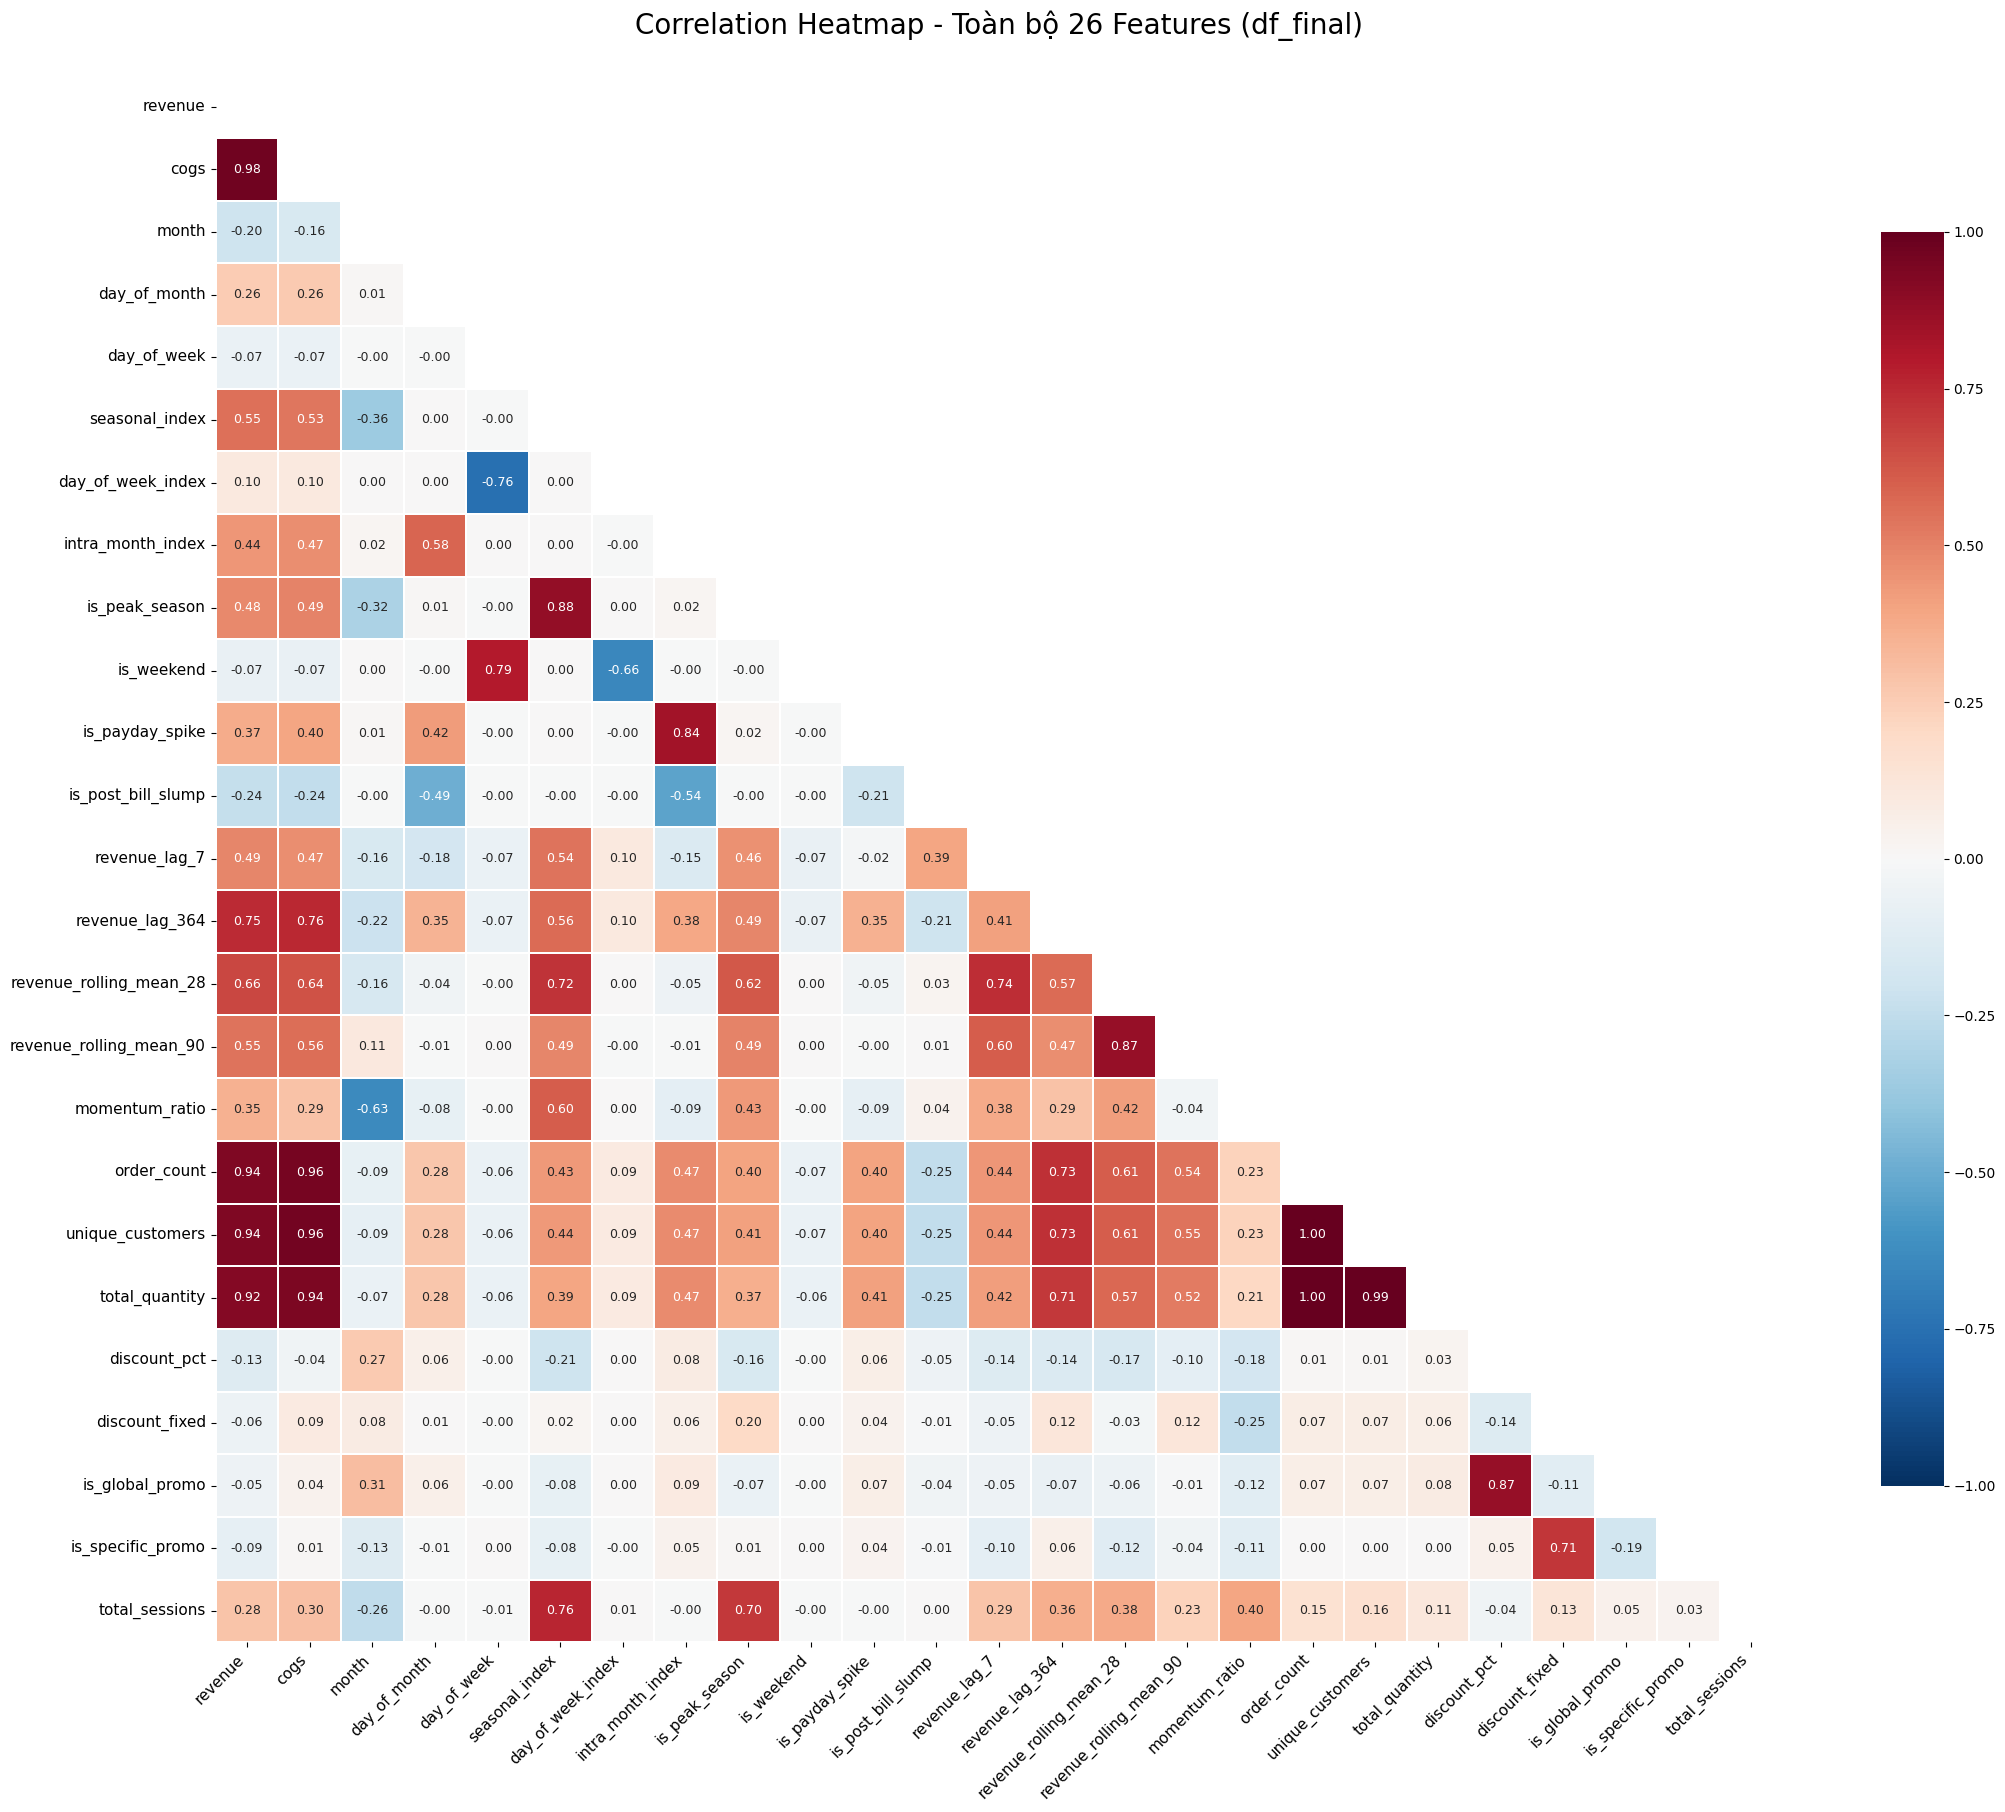

In [106]:
def plot_final_heatmap(df):
    # 1. Chỉ lấy các cột dữ liệu số
    df_numeric = df.select_dtypes(include=[np.number])
    
    # 2. Tính ma trận tương quan
    corr = df_numeric.corr()
    
    # 3. Tạo mask che đi nửa trên để dễ nhìn hơn
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # 4. Thiết lập kích thước lớn (20x16) để hiển thị rõ 26 features
    plt.figure(figsize=(22, 18))
    
    # 5. Vẽ heatmap
    sns.heatmap(
        corr, 
        mask=mask, 
        annot=True,          # Hiện số
        fmt=".2f",           # Lấy 2 chữ số thập phân
        cmap='RdBu_r',       # Màu Đỏ (dương) - Trắng (0) - Xanh (âm)
        center=0,
        vmin=-1, vmax=1,
        square=True, 
        linewidths=.3,
        cbar_kws={"shrink": .8},
        annot_kws={"size": 9} # Cỡ chữ số nhỏ lại để không bị đè nhau
    )
    
    plt.title('Correlation Heatmap - Toàn bộ 26 Features (df_final)', fontsize=20, pad=30)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.show()

# Thực thi vẽ biểu đồ
plot_final_heatmap(df_final)

**Nhật xét**:
- Các đặc trưng có mức độ tương quan cao với `revenue` như : `cogs`,`unique_customers` và `order_count` sẽ được loại bỏ hoặc thay thế bằng mội biến khác liên quan hoặc lùi về quá khứ để tránh mô hình bị overfitting
- `revenue_rolling_mean_90` đang có mức tương quan cao với `revenue_rolling_mean_28`, vì vậy sẽ xóa `revenue_rolling_mean_90`
- `total_quantity` sẽ là một đặc trưng tốt để phân biệt giữa những ngày có giảm giá so với những ngày thường, chúng tôi sẽ tạo một mô hình dự đoán khác để dự đoán cho `total_quantity` trước khi dự đoán `revenue`
- `total_sessions` có mức độ tương quan khác ổn áp, ngoài ra xu hướng của nó có tính mùa vụ và xu hướng tăng lên qua các năm, chúng tôi sẽ khai phá đặc trưng này bằng cách huấn luyện thêm một mô hình nữa để dự đoán `total_sessios` cho tương lai trước khi đưa vào dự đoán `revenue`

In [107]:
import pandas as pd

def preprocess_df_final(df):
    print("🧹 Bắt đầu dọn dẹp và tiền xử lý df_final...")
    # Tạo bản sao để không làm hỏng dữ liệu gốc
    df_clean = df.copy()
    
    # Đảm bảo dữ liệu được sắp xếp chuẩn theo thời gian trước khi dùng hàm shift
    df_clean['date'] = pd.to_datetime(df_clean['date'])
    df_clean = df_clean.sort_values('date').reset_index(drop=True)
    
    # ---------------------------------------------------------
    # BƯỚC 1: XÓA CÁC CỘT RÒ RỈ, TRÙNG LẶP VÀ NGÀY THÁNG THÔ
    # ---------------------------------------------------------
    cols_to_drop = [
        'cogs',                     # Rò rỉ tương lai tuyệt đối (Leakage)
        'unique_customers',         # Đa cộng tuyến (trùng 99% với order_count)
        'revenue_rolling_mean_90',  # Đa cộng tuyến (trùng 95% với seasonal_index)
        'month',                    # Đã có intra_month_index và seasonal_index lo
        'day_of_month',             # Đã có intra_month_index
        'day_of_week',              # Đã có day_of_week_index
        'is_weekend'                # Trùng lặp thông tin với day_of_week_index
    ]
    
    # Lọc những cột thực sự tồn tại trong df để lệnh drop không bị lỗi
    cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
    df_clean = df_clean.drop(columns=cols_to_drop)
    
    # ---------------------------------------------------------
    # BƯỚC 2: FEATURE ENGINEERING CHO NHÓM HÀNH VI
    # ---------------------------------------------------------
    # Với số lượng đơn hàng (order_count), ta không được dùng số hiện tại.
    # Ta sẽ đẩy nó về quá khứ 7 ngày để tạo "Mỏ neo hành vi mua sắm của tuần trước"
    if 'order_count' in df_clean.columns:
        df_clean['order_count_lag_7'] = df_clean['order_count'].shift(7)
        # Xóa thẳng tay cột order_count hiện tại để khóa chặn rò rỉ dữ liệu
        df_clean = df_clean.drop(columns=['order_count'])
    
    # LƯU Ý: Tại sao ta KHÔNG xóa 'total_sessions' và 'total_quantity'?
    # Vì chúng ta sẽ dùng chúng làm Biến mục tiêu (Target) cho Mô hình Giai đoạn 1
    # (Dự đoán Traffic và Dự đoán sức mua), sau đó mới đưa vào mô hình Doanh thu.
    
    # ---------------------------------------------------------
    # BƯỚC 3: XÓA CÁC DÒNG RỖNG (NaN) DO HÀM SHIFT TẠO RA
    # ---------------------------------------------------------
    # Việc shift 7 ngày sẽ làm 7 dòng đầu tiên bị NaN, ta cần cắt bỏ chúng
    initial_shape = df.shape
    df_clean = df_clean.dropna().reset_index(drop=True)
    
    print(f"✅ Dọn dẹp hoàn tất!")
    print(f"📉 Số lượng features (cột) giảm từ {initial_shape[1]} xuống còn {df_clean.shape[1]}")
    print(f"✂️ Cắt bỏ {initial_shape[0] - df_clean.shape[0]} dòng đầu tiên do chứa NaN từ biến Lag.")
    
    return df_clean


In [132]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error

def predict_total_sessions(df, train_end='2021-12-31', val_start='2022-01-01', val_end='2022-12-31'):
    print("🚀 Bắt đầu Mô hình Giai đoạn 1: Dự đoán Total Sessions...")
    df = df.copy()
    
    # 1. Feature Engineering (Chỉ dành riêng cho total_sessions)
    # Tạo các biến trễ (lag) của chính total_sessions để làm quán tính
    df['total_sessions_lag_28'] = df['total_sessions'].shift(28)
    df['total_sessions_lag_364'] = df['total_sessions'].shift(364)
    df['total_sessions_rolling_364'] = df['total_sessions'].shift(1).rolling(364).mean()
    df['total_sessions_rolling_28'] = df['total_sessions'].shift(1).rolling(28).mean()
    df['raito'] = df['total_sessions_rolling_28'] / (df['total_sessions_rolling_364'] + 1e-5)  # Thêm epsilon để tránh chia cho 0
    
    # Bỏ các dòng NaN do shift tạo ra
    df = df.dropna(subset=['total_sessions_lag_28', 'total_sessions_lag_364', 'total_sessions_rolling_28', 'total_sessions_rolling_364', 'raito']).reset_index(drop=True)
    
    # Chọn features: KHÔNG dùng bất kỳ biến nào rò rỉ từ doanh thu/đơn hàng
    traffic_features = [
        'seasonal_index', 'day_of_week_index', 'intra_month_index',
        'total_sessions_lag_28', 'total_sessions_lag_364', 'total_sessions_rolling_28', 'total_sessions_rolling_364', 'raito'
    ]
    target = 'total_sessions'

    # 2. Chia tập Train và Validation
    train = df[df['date'] <= train_end].copy()
    val = df[(df['date'] >= val_start) & (df['date'] <= val_end)].copy()
    
    X_train, y_train = train[traffic_features], train[target]
    X_val, y_val = val[traffic_features], val[target]

    # --- BƯỚC QUAN TRỌNG: TẠO OUT-OF-FOLD PREDICTION CHO TẬP TRAIN ---
    # Nếu lấy model train xong đi dự đoán lại X_train thì điểm sẽ quá hoàn hảo (Leakage)
    # Ta dùng TimeSeriesSplit để dự đoán cuốn chiếu
    print(" Đang tạo Out-of-Fold Predictions cho tập Train...")
    tscv = TimeSeriesSplit(n_splits=5)
    train['predicted_total_sessions'] = np.nan
    
    # Dùng model mặc định cho nhanh
    oof_model = lgb.LGBMRegressor(random_state=42, n_estimators=100, verbose=-1)
    
    for train_index, test_index in tscv.split(X_train):
        cv_X_train, cv_X_test = X_train.iloc[train_index], X_train.iloc[test_index]
        cv_y_train = y_train.iloc[train_index]
        
        oof_model.fit(cv_X_train, cv_y_train)
        train.loc[train.index[test_index], 'predicted_total_sessions'] = oof_model.predict(cv_X_test)
        
    # Điền những dòng đầu tiên (không có lịch sử cross-val) bằng giá trị trung bình để không bị NaN
    train['predicted_total_sessions'] = train['predicted_total_sessions'].fillna(train['total_sessions'].mean())

    # --- BƯỚC 3: HUẤN LUYỆN MÔ HÌNH CHÍNH & DỰ ĐOÁN TẬP VAL ---
    print(" Đang huấn luyện mô hình dự báo tương lai...")
    final_model = lgb.LGBMRegressor(random_state=42, n_estimators=200, learning_rate=0.05, verbose=-1)
    final_model.fit(X_train, y_train)
    
    val['predicted_total_sessions'] = final_model.predict(X_val)

    # Đánh giá sai số dự đoán Traffic
    mape_val = mean_absolute_percentage_error(val[target], val['predicted_total_sessions']) * 100
    print(f"✅ Hoàn tất! Sai số (MAPE) dự đoán Traffic trên tập Val: {mape_val:.2f}%")
    
    # Gộp lại thành một bảng hoàn chỉnh
    df_result = pd.concat([train, val]).sort_values('date').reset_index(drop=True)
    
    return df_result, final_model

# Cách sử dụng:
# Giả sử bạn đang có tập df_final (đã làm sạch các cột cogs, unique_customers...)
df_cleaned = preprocess_df_final(df_final)
df_with_predicted_traffic, traffic_model = predict_total_sessions(df_cleaned)

# Xem thử kết quả
df_with_predicted_traffic[['date', 'total_sessions', 'predicted_total_sessions']].tail(10)

🧹 Bắt đầu dọn dẹp và tiền xử lý df_final...
✅ Dọn dẹp hoàn tất!
📉 Số lượng features (cột) giảm từ 26 xuống còn 19
✂️ Cắt bỏ 364 dòng đầu tiên do chứa NaN từ biến Lag.
🚀 Bắt đầu Mô hình Giai đoạn 1: Dự đoán Total Sessions...
 Đang tạo Out-of-Fold Predictions cho tập Train...
 Đang huấn luyện mô hình dự báo tương lai...
✅ Hoàn tất! Sai số (MAPE) dự đoán Traffic trên tập Val: 7.35%


,date,total_sessions,predicted_total_sessions
3095,2022-12-22,20194.0,19874.662318
3096,2022-12-23,18193.0,20073.290645
3097,2022-12-24,19257.0,19675.650791
3098,2022-12-25,19815.0,19680.486711
3099,2022-12-26,21676.0,21234.889722
3100,2022-12-27,17416.0,21176.119448
3101,2022-12-28,21071.0,21060.561076
3102,2022-12-29,20884.0,20360.011795
3103,2022-12-30,17679.0,20054.843689
3104,2022-12-31,21743.0,20229.162942


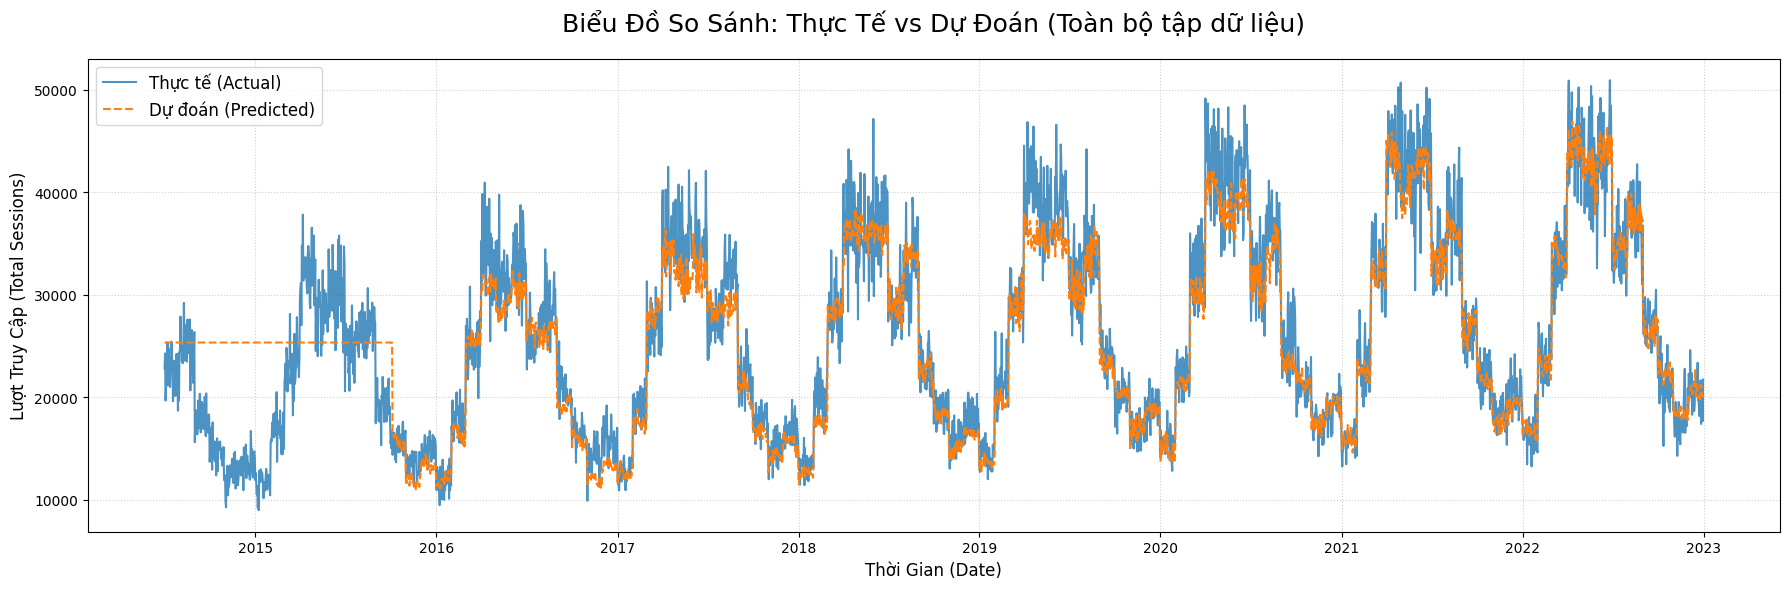

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_actual_vs_predicted(df, date_col='date', actual_col='total_sessions', pred_col='predicted_total_sessions', zoom_val_only=True):
    """
    Hàm vẽ biểu đồ so sánh giữa Dữ liệu thực tế và Dữ liệu dự đoán.
    
    Tham số:
    - zoom_val_only: Nếu True, chỉ vẽ từ năm 2022 trở đi (tập Validation) để biểu đồ không bị quá rải rác. 
                     Nếu False, vẽ toàn bộ lịch sử.
    """
    df_plot = df.copy()
    df_plot[date_col] = pd.to_datetime(df_plot[date_col])
    
    # Cắt dữ liệu để zoom vào tập Validation (nếu cần) cho dễ nhìn
    if zoom_val_only:
        df_plot = df_plot[df_plot[date_col] >= '2022-01-01']
        title_suffix = "(Tập Validation - Năm 2022)"
    else:
        title_suffix = "(Toàn bộ tập dữ liệu)"
        
    df_plot = df_plot.sort_values(by=date_col)
    
    # Kích thước biểu đồ
    plt.figure(figsize=(18, 6))
    
    # Vẽ đường Thực tế (Actual)
    sns.lineplot(
        x=df_plot[date_col], 
        y=df_plot[actual_col], 
        label='Thực tế (Actual)', 
        color='#1f77b4', # Màu xanh dương
        linewidth=1.5,
        alpha=0.8
    )
    
    # Vẽ đường Dự đoán (Predicted)
    sns.lineplot(
        x=df_plot[date_col], 
        y=df_plot[pred_col], 
        label='Dự đoán (Predicted)', 
        color='#ff7f0e', # Màu cam
        linewidth=1.5,
        linestyle='--'   # Nét đứt để dễ phân biệt
    )
    
    # Định dạng lại biểu đồ cho đẹp
    plt.title(f'Biểu Đồ So Sánh: Thực Tế vs Dự Đoán {title_suffix}', fontsize=18, pad=20)
    plt.xlabel('Thời Gian (Date)', fontsize=12)
    plt.ylabel('Lượt Truy Cập (Total Sessions)', fontsize=12)
    
    # Thêm lưới (Grid) để dễ gióng số
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Làm nổi bật phần chú thích (Legend)
    plt.legend(fontsize=12, loc='upper left')
    
    # Tối ưu khoảng trống
    plt.tight_layout()
    plt.show()


plot_actual_vs_predicted(df_with_predicted_traffic, actual_col='total_sessions', pred_col='predicted_total_sessions', zoom_val_only=False)

In [110]:
import pandas as pd

def process_and_clean_features(df):
    print("🧹 Bắt đầu xử lý tính năng và dọn dẹp dữ liệu...")
    df_clean = df.copy()
    
    # 1. Đảm bảo dữ liệu sắp xếp chuẩn theo thời gian
    df_clean['date'] = pd.to_datetime(df_clean['date'])
    df_clean = df_clean.sort_values('date').reset_index(drop=True)
    
    # =========================================================
    # BƯỚC 1: TẠO BIẾN ĐỒNG BỘ CHO SỨC MUA (TOTAL_QUANTITY)
    # =========================================================
    # Lùi 7 ngày và 364 ngày (để giữ nguyên thứ trong tuần)
    df_clean['quantity_lag_7'] = df_clean['total_quantity'].shift(7)
    df_clean['quantity_lag_364'] = df_clean['total_quantity'].shift(364)
    
    # Trung bình trượt 28 ngày qua (Đà mua sắm)
    df_clean['quantity_rolling_mean_28'] = df_clean['total_quantity'].shift(1).rolling(28).mean()
    
    # =========================================================
    # BƯỚC 2: TÍNH LẠI ĐÀ TĂNG TRƯỞNG (NGẮN HẠN & DÀI HẠN)
    # =========================================================
    # 2.1. Ngắn hạn (Micro-Momentum): Tuần trước so với trung bình 1 tháng qua đang tốt hay xấu?
    df_clean['micro_momentum_ratio'] = df_clean['revenue_lag_7'] / (df_clean['revenue_rolling_mean_28'] + 1e-5)
    
    # 2.2. Dài hạn (YoY Growth): Sức khỏe tháng này so với ĐÚNG THÁNG NÀY NĂM NGOÁI
    # Lấy trung bình 28 ngày của năm ngoái làm hệ quy chiếu
    df_clean['revenue_rolling_28_lag_364'] = df_clean['revenue_rolling_mean_28'].shift(364)
    # Tỷ lệ tăng trưởng năm (Nhận diện suy thoái hoặc bùng nổ vĩ mô)
    df_clean['yoy_growth_ratio'] = df_clean['revenue_rolling_mean_28'] / (df_clean['revenue_rolling_28_lag_364'] + 1e-5)
    
    # =========================================================
    # BƯỚC 3: DỌN DẸP "RÁC" VÀ BIẾN RÒ RỈ (DATA LEAKAGE)
    # =========================================================
    cols_to_drop = [
        'cogs',                       # Leakage (Biết giá vốn tức là biết doanh thu)
        'unique_customers',           # Leakage & Trùng lặp
        'order_count',                # Leakage (Chính là total_orders bạn nhắc đến)
        'total_quantity',             # Leakage (Đã trích xuất xong toàn bộ tinh hoa vào lag/rolling)
        'revenue_rolling_mean_90',    # Đa cộng tuyến (Trùng lặp với seasonal_index)
        'momentum_ratio',             # Dư thừa (Đã được thay bằng micro_momentum_ratio)
        'revenue_rolling_28_lag_364'  # Xóa biến phụ trợ dùng để tính YoY cho gọn data
    ]
    
    # Chỉ xóa những cột thực sự tồn tại để tránh báo lỗi
    cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
    df_clean = df_clean.drop(columns=cols_to_drop)
    
    # =========================================================
    # BƯỚC 4: LỌC BỎ CÁC DÒNG RỖNG (NaN)
    # =========================================================
    initial_rows = df_clean.shape[0]
    # Lệnh shift(364) sẽ tạo ra 364 dòng đầu tiên bị NaN, bắt buộc phải cắt bỏ
    df_clean = df_clean.dropna().reset_index(drop=True)
    
    print("✅ Hoàn tất xử lý!")
    print(f"✂️ Đã cắt bỏ {initial_rows - df_clean.shape[0]} dòng thiếu dữ liệu lịch sử.")
    print(f"📉 Số lượng cột cuối cùng: {df_clean.shape[1]} cột.")
    
    return df_clean

# Cách gọi hàm với tập dữ liệu của bạn:
df_ready = process_and_clean_features(df_final)
display(df_ready.head())

🧹 Bắt đầu xử lý tính năng và dọn dẹp dữ liệu...
✅ Hoàn tất xử lý!
✂️ Đã cắt bỏ 371 dòng thiếu dữ liệu lịch sử.
📉 Số lượng cột cuối cùng: 25 cột.


,date,revenue,month,day_of_month,day_of_week,seasonal_index,day_of_week_index,intra_month_index,is_peak_season,is_weekend,...,discount_pct,discount_fixed,is_global_promo,is_specific_promo,total_sessions,quantity_lag_7,quantity_lag_364,quantity_rolling_mean_28,micro_momentum_ratio,yoy_growth_ratio
0,2013-07-10,3855254.64,7,10,2,1.115,1.057,0.808661,1,0,...,18.0,0.0,1.0,0.0,22911.0,1866.0,1097.0,1280.607143,1.370027,1.660078
1,2013-07-11,5785320.61,7,11,3,1.115,1.023,0.850650,1,0,...,18.0,0.0,1.0,0.0,22159.0,483.0,1241.0,1259.428571,0.438661,1.516342
2,2013-07-12,6053300.71,7,12,4,1.115,0.938,0.880717,1,0,...,18.0,0.0,1.0,0.0,21395.0,553.0,995.0,1264.750000,0.436805,1.425136
3,2013-07-13,4161301.31,7,13,5,1.115,0.918,0.887937,1,1,...,18.0,0.0,1.0,0.0,20990.0,499.0,751.0,1280.607143,0.426345,1.390452
4,2013-07-14,4482102.22,7,14,6,1.115,0.971,0.922253,1,1,...,18.0,0.0,1.0,0.0,19989.0,568.0,732.0,1278.892857,0.517514,1.391439


📊 Đang vẽ biểu đồ tương quan...


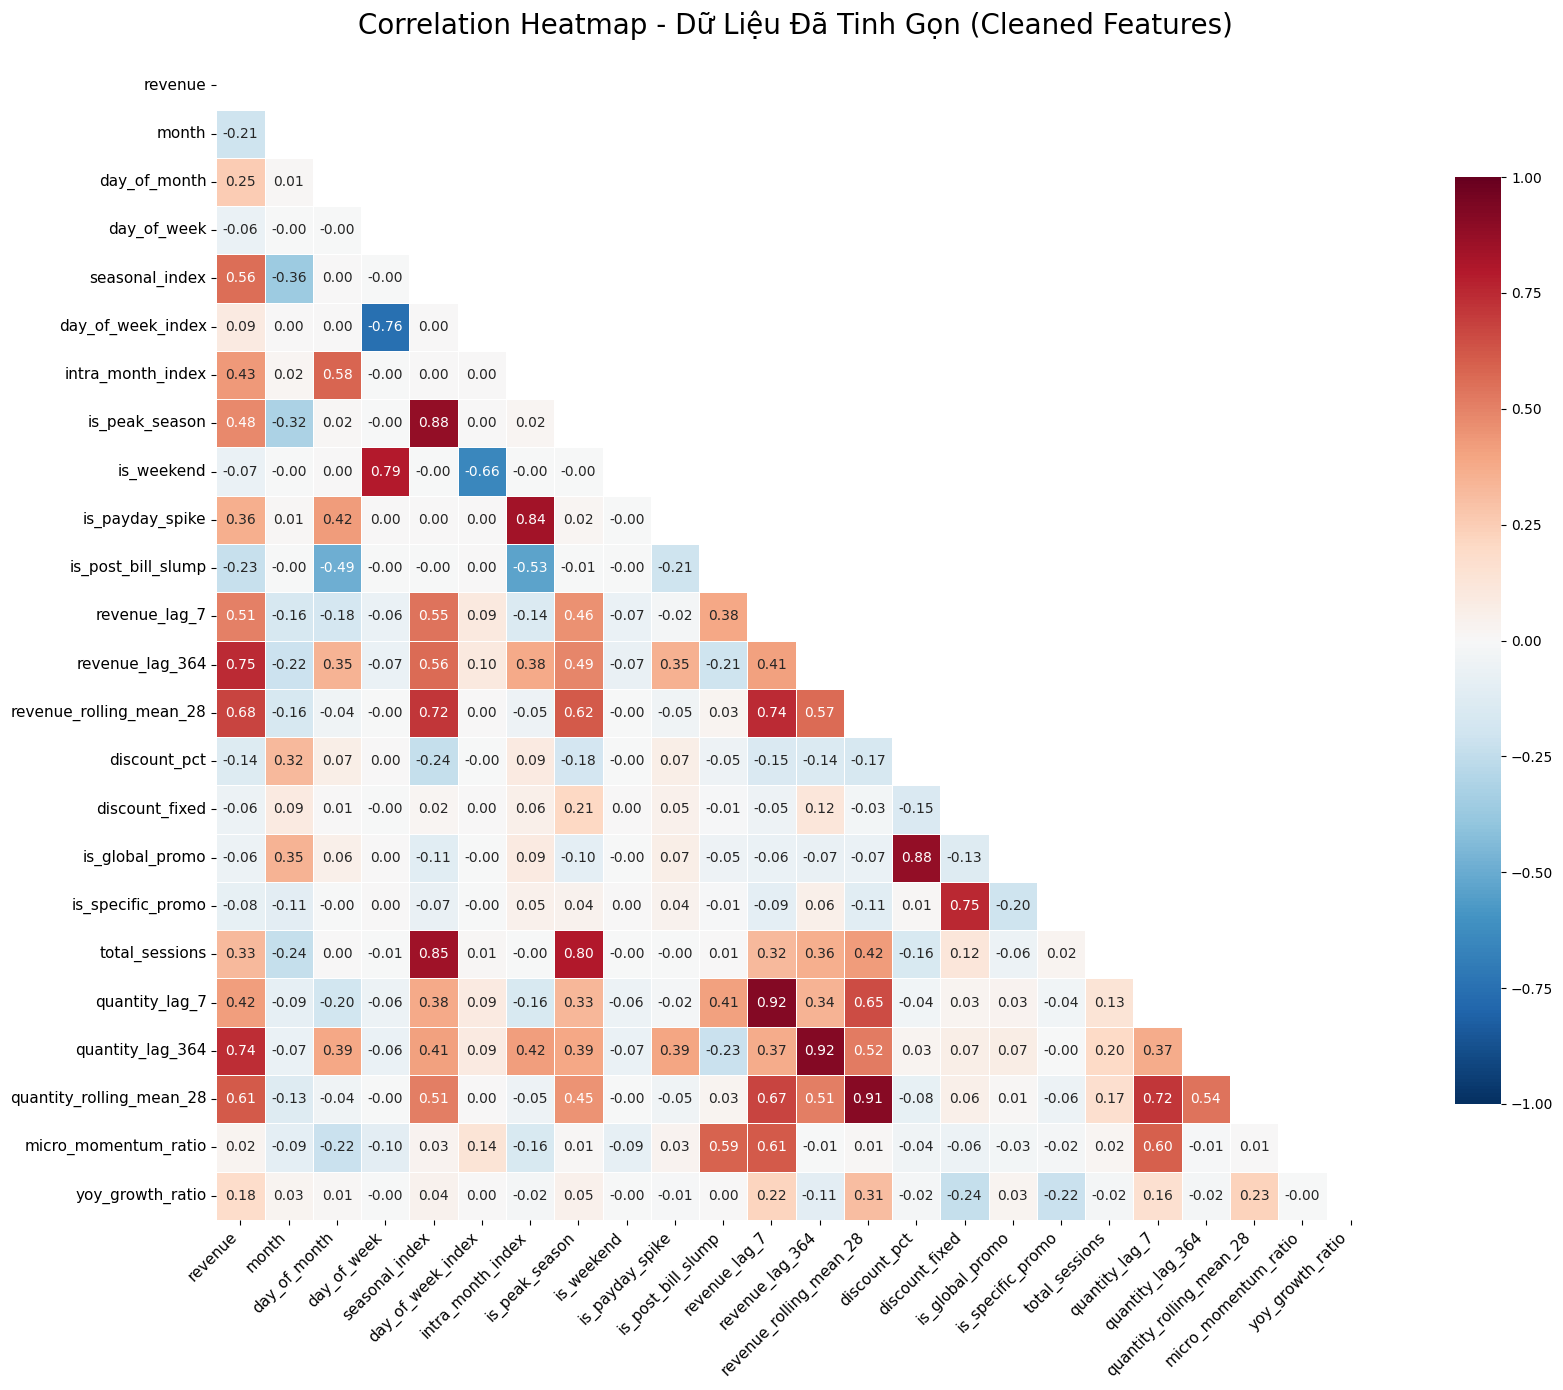

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_clean_heatmap(df):
    print("📊 Đang vẽ biểu đồ tương quan...")
    
    # 1. Chỉ lấy các cột chứa dữ liệu số
    df_numeric = df.select_dtypes(include=[np.number])
    
    # 2. Tính toán ma trận tương quan (Pearson)
    corr = df_numeric.corr()
    
    # 3. Tạo mask để che đi nửa tam giác phía trên (tránh trùng lặp thị giác)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # 4. Cài đặt kích thước biểu đồ (Thu gọn lại một chút vì số features đã giảm)
    plt.figure(figsize=(18, 14))
    
    # 5. Vẽ Heatmap
    sns.heatmap(
        corr, 
        mask=mask, 
        annot=True,          # Hiển thị con số
        fmt=".2f",           # Lấy 2 chữ số thập phân
        cmap='RdBu_r',       # Thang màu Đỏ (Tương quan dương) - Trắng (0) - Xanh (Tương quan âm)
        center=0,
        vmin=-1, vmax=1,
        square=True, 
        linewidths=.5,       # Viền chia các ô
        cbar_kws={"shrink": .8},
        annot_kws={"size": 10} # Kích thước chữ số
    )
    
    plt.title('Correlation Heatmap - Dữ Liệu Đã Tinh Gọn (Cleaned Features)', fontsize=20, pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.show()

# ==========================================
# CÁCH SỬ DỤNG:
# Truyền tập dữ liệu df_ready (output của bước xử lý trước) vào hàm
plot_clean_heatmap(df_ready)

## 4. Kiểm tra độ mạnh của từng features

In [112]:
# Thêm cột sessions dự đoán vào df_ready để có thể đánh giá tương quan với doanh thu
df_ready['predicted_total_sessions'] = df_with_predicted_traffic['predicted_total_sessions']
df_ready.drop(columns=['total_sessions'], inplace=True)

df_ready.info()

<class 'pandas.DataFrame'>
RangeIndex: 3462 entries, 0 to 3461
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      3462 non-null   datetime64[us]
 1   revenue                   3462 non-null   float64       
 2   month                     3462 non-null   int64         
 3   day_of_month              3462 non-null   int64         
 4   day_of_week               3462 non-null   int64         
 5   seasonal_index            3462 non-null   float64       
 6   day_of_week_index         3462 non-null   float64       
 7   intra_month_index         3462 non-null   float64       
 8   is_peak_season            3462 non-null   int64         
 9   is_weekend                3462 non-null   int64         
 10  is_payday_spike           3462 non-null   int64         
 11  is_post_bill_slump        3462 non-null   int64         
 12  revenue_lag_7             3462 

In [113]:
from src.baseline_models import evaluate_vanilla_lightgbm, get_feature_importances
target = 'revenue'
feature_cols = [col for col in df_ready.columns if col not in ['date', target]]

df_val, model, metrics_lgbm = evaluate_vanilla_lightgbm(df_ready, target_col=target, features_col=feature_cols)

print(f"\n--- KẾT QUẢ ĐÁNH GIÁ VANILLA LIGHTGBM MODEL VỚI {len(feature_cols)} FEATURES ---")
print(f"MAE  (Sai số tuyệt đối)   : {metrics_lgbm['MAE']:,.2f}")
print(f"RMSE (Sai số bình phương) : {metrics_lgbm['RMSE']:,.2f}")
print(f"MAPE (Sai số phần trăm)   : {metrics_lgbm['MAPE']:.2f}%")
print(f"R-squared (Độ phù hợp)    : {metrics_lgbm['R-squared']:.4f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[31]	training's rmse: 822845	training's l2: 6.77073e+11	valid_1's rmse: 718523	valid_1's l2: 5.16275e+11

--- KẾT QUẢ ĐÁNH GIÁ VANILLA LIGHTGBM MODEL VỚI 23 FEATURES ---
MAE  (Sai số tuyệt đối)   : 604,479.15
RMSE (Sai số bình phương) : 718,523.11
MAPE (Sai số phần trăm)   : 53.76%
R-squared (Độ phù hợp)    : 0.0948


c:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\src\baseline_models.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


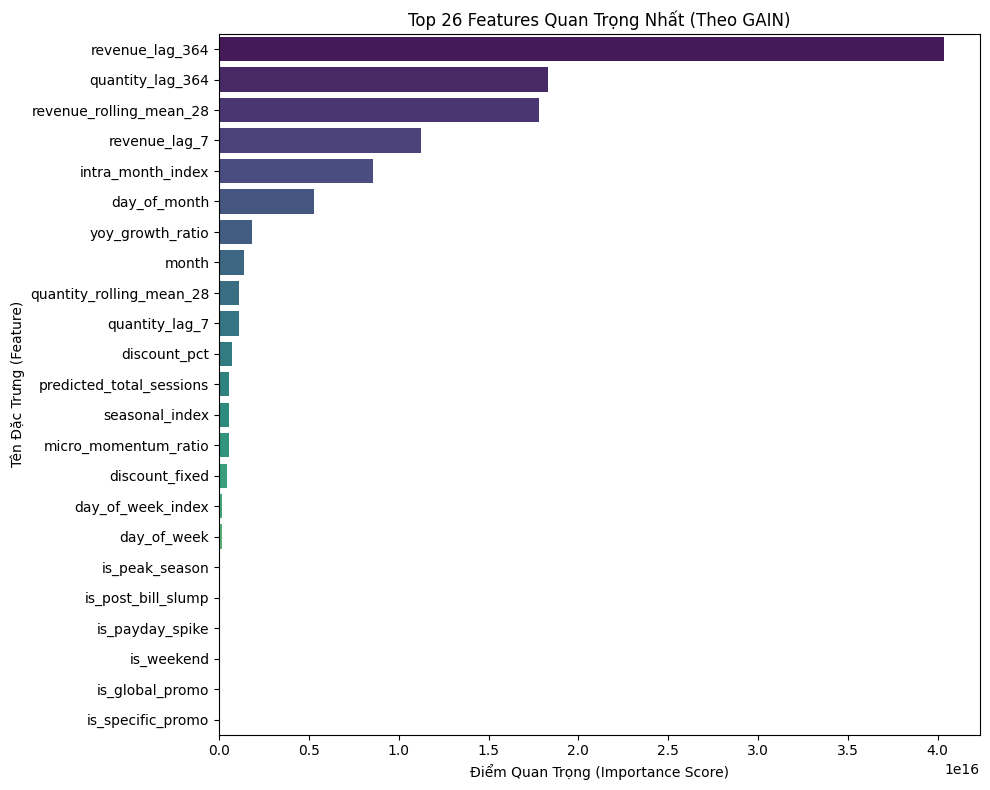

In [114]:
# Đánh giá mức độ đóng góp của từng feature vào mô hình
top_features = get_feature_importances(model, top_n=26)

🧠 Đang tính toán giá trị SHAP (có thể mất vài chục giây tùy lượng dữ liệu)...


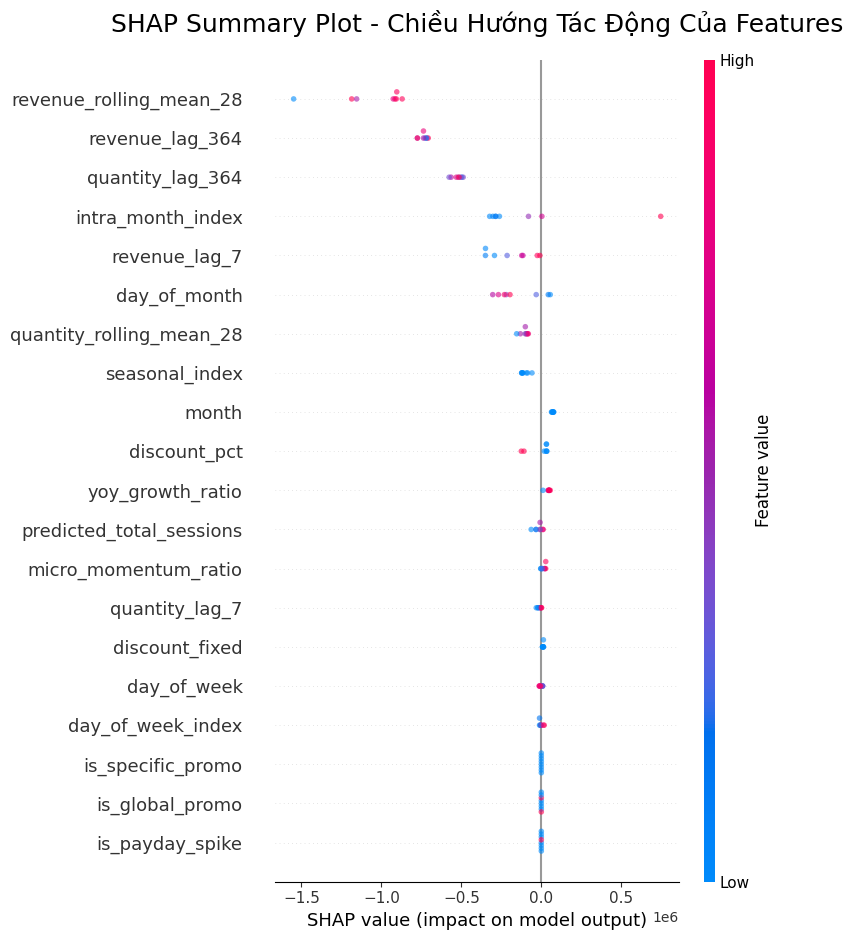

In [115]:
import shap
import matplotlib.pyplot as plt

X_val = df_val[feature_cols]

def plot_shap_summary(model, X_val):
    print("🧠 Đang tính toán giá trị SHAP (có thể mất vài chục giây tùy lượng dữ liệu)...")
    
    # 1. Khởi tạo explainer chuyên dụng cho mô hình dạng Cây (LightGBM)
    explainer = shap.TreeExplainer(model)
    
    # 2. Tính toán SHAP values trên tập Validation (X_val)
    # Lưu ý: LightGBM có thể trả về list hoặc array tùy phiên bản, ta lấy phần tử đầu tiên nếu là list
    shap_values = explainer.shap_values(X_val)
    if isinstance(shap_values, list):
        shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]
        
    # 3. Vẽ biểu đồ Summary Plot dạng chấm (dot)
    plt.figure(figsize=(14, 10))
    
    # plot_type="dot" là dạng chuẩn và đẹp nhất của SHAP
    shap.summary_plot(
        shap_values, 
        X_val, 
        plot_type="dot", 
        show=False,
        alpha=0.6 # Làm mờ các chấm để nhìn rõ mật độ tập trung
    )
    
    # 4. Tinh chỉnh hiển thị
    plt.title('SHAP Summary Plot - Chiều Hướng Tác Động Của Features', fontsize=18, pad=20)
    plt.tight_layout()
    plt.show()

plot_shap_summary(model, X_val)

## 5. Tối ưu tham số

In [116]:
from src.baseline_models import get_best_lgb_params
target = 'revenue'
feature_cols = [col for col in df_ready.columns if col not in ['date', target]]

best_params = get_best_lgb_params(df_ready, target_col=target, features_col=feature_cols, n_trials=50)
print("🚀 Đang huấn luyện lại LightGBM với tham số tối ưu hóa...")
print("Tham số tối ưu đã tìm được:")
for param, value in best_params.items():
    print(f" - {param}: {value}")

Đang tiến hành tìm kiếm tham số tối ưu với 50 quá trình (trials)...
Min RMSE: 524223.1298
🚀 Đang huấn luyện lại LightGBM với tham số tối ưu hóa...
Tham số tối ưu đã tìm được:
 - learning_rate: 0.08010996019249317
 - num_leaves: 56
 - max_depth: 8
 - feature_fraction: 0.49069447659877125
 - bagging_fraction: 0.5748637746082426
 - bagging_freq: 5
 - min_child_samples: 100
 - lambda_l1: 0.006933215262378755
 - lambda_l2: 0.04352704595517211


In [117]:
# Sử dụng tham số tối ưu để huấn luyện lại mô hình
df_val, model, metrics_lgbm = evaluate_vanilla_lightgbm(df_ready, target_col=target, features_col=feature_cols, best_lgb_params=best_params)

print(f"\n--- KẾT QUẢ ĐÁNH GIÁ VANILLA LIGHTGBM MODEL VỚI {len(feature_cols)} FEATURES ---")
print(f"MAE  (Sai số tuyệt đối)   : {metrics_lgbm['MAE']:,.2f}")
print(f"RMSE (Sai số bình phương) : {metrics_lgbm['RMSE']:,.2f}")
print(f"MAPE (Sai số phần trăm)   : {metrics_lgbm['MAPE']:.2f}%")
print(f"R-squared (Độ phù hợp)    : {metrics_lgbm['R-squared']:.4f}")

Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 1.02441e+06	training's l2: 1.04942e+12	valid_1's rmse: 602045	valid_1's l2: 3.62459e+11
Early stopping, best iteration is:
[60]	training's rmse: 1.12109e+06	training's l2: 1.25685e+12	valid_1's rmse: 524223	valid_1's l2: 2.7481e+11

--- KẾT QUẢ ĐÁNH GIÁ VANILLA LIGHTGBM MODEL VỚI 23 FEATURES ---
MAE  (Sai số tuyệt đối)   : 397,393.19
RMSE (Sai số bình phương) : 524,223.13
MAPE (Sai số phần trăm)   : 39.03%
R-squared (Độ phù hợp)    : 0.5182


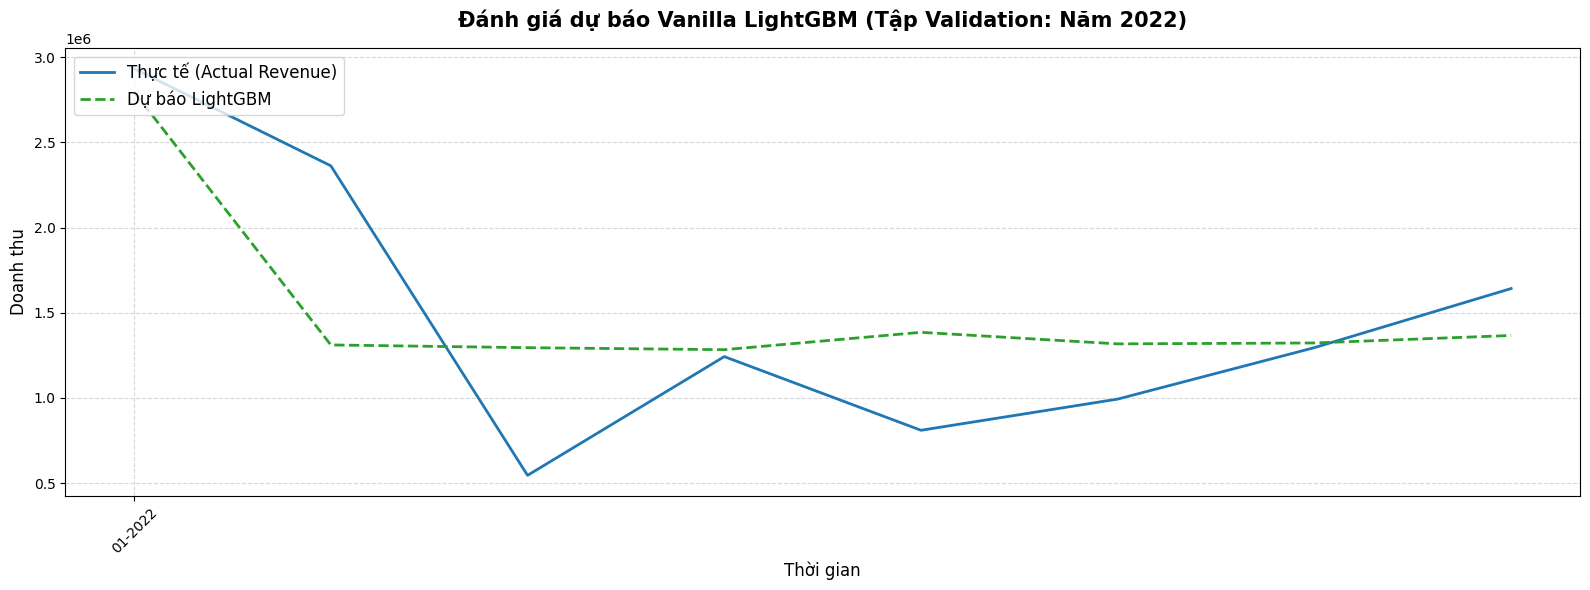

In [118]:
plt.figure(figsize=(16, 6))

# Vẽ 2 đường Thực tế (Màu xanh) và Dự báo LightGBM (Màu xanh lá)
plt.plot(df_val['date'], df_val['revenue'], label='Thực tế (Actual Revenue)', color='#1f77b4', linewidth=2)
plt.plot(df_val['date'], df_val['lgbm_revenue'], label='Dự báo LightGBM', color='#2ca02c', linestyle='--', linewidth=2)

# Trang trí tiêu đề và nhãn
plt.title('Đánh giá dự báo Vanilla LightGBM (Tập Validation: Năm 2022)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Doanh thu', fontsize=12)

# Định dạng trục X hiển thị theo từng tháng
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.xticks(rotation=45) # Xoay 45 độ cho dễ đọc

# Thêm lưới và chú thích
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

---
**Kết luận:**

---
**Notebooks tiếp theo:** []() - 